In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = next(
    parent for parent in [Path.cwd(), *Path.cwd().parents] if (parent / "src").is_dir()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.loader import load_transactions

DATASET_PATH = PROJECT_ROOT / "data" / "raw" / "online_retail_II.xlsx"
df = load_transactions(DATASET_PATH)
df.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom


## Dataset overview

The dataset is loaded through the project loader, which reads both Excel sheets and normalizes the source columns. The first checks describe the dataset size and data types.

In [2]:
import pandas as pd

overview = pd.DataFrame(
    {
        "metric": [
            "rows",
            "columns",
            "unique_invoices",
            "unique_products",
            "unique_customers",
            "date_from",
            "date_to",
        ],
        "value": [
            len(df),
            df.shape[1],
            df["invoice_no"].nunique(),
            df["stock_code"].nunique(),
            df["customer_id"].nunique(),
            df["invoice_date"].min(),
            df["invoice_date"].max(),
        ],
    }
)
overview

,metric,value
0,rows,1067371
1,columns,8
2,unique_invoices,53628
3,unique_products,5305
4,unique_customers,5942
5,date_from,2009-12-01 07:45:00
6,date_to,2011-12-09 12:50:00


## Data quality checks

The Online Retail II dataset contains canceled invoices and transactions without a customer identifier. These records are not removed in the exploratory stage; instead, they are measured explicitly before preprocessing.

In [3]:
quality = pd.DataFrame(
    {
        "metric": [
            "missing_customer_id",
            "missing_description",
            "duplicate_rows",
            "negative_quantity_rows",
            "zero_price_rows",
        ],
        "count": [
            df["customer_id"].isna().sum(),
            df["description"].isna().sum(),
            df.duplicated().sum(),
            (df["quantity"] < 0).sum(),
            (df["unit_price"] == 0).sum(),
        ],
    }
)
quality["share_percent"] = (quality["count"] / len(df) * 100).round(2)
quality

,metric,count,share_percent
0,missing_customer_id,243007,22.77
1,missing_description,4382,0.41
2,duplicate_rows,34335,3.22
3,negative_quantity_rows,22950,2.15
4,zero_price_rows,6202,0.58


## Sales analysis

Revenue is calculated at line-item level as `quantity * unit_price`. For the first business view, sales and returns are shown separately.

In [4]:
analysis_df = df.copy()
analysis_df["revenue"] = analysis_df["quantity"] * analysis_df["unit_price"]
analysis_df["month"] = analysis_df["invoice_date"].dt.to_period("M").astype(str)
analysis_df["is_return"] = analysis_df["quantity"] < 0

sales_summary = pd.DataFrame(
    {
        "metric": [
            "gross_revenue",
            "return_value",
            "net_revenue",
            "sales_lines",
            "return_lines",
            "average_line_value",
        ],
        "value": [
            analysis_df.loc[~analysis_df["is_return"], "revenue"].sum(),
            analysis_df.loc[analysis_df["is_return"], "revenue"].sum(),
            analysis_df["revenue"].sum(),
            (~analysis_df["is_return"]).sum(),
            analysis_df["is_return"].sum(),
            analysis_df["revenue"].mean(),
        ],
    }
)
sales_summary

,metric,value
0,gross_revenue,2.081429e+07
1,return_value,-1.527041e+06
2,net_revenue,1.928725e+07
3,sales_lines,1.044421e+06
4,return_lines,2.295000e+04
5,average_line_value,1.806987e+01


In [5]:
monthly_sales = (
    analysis_df.loc[~analysis_df["is_return"]]
    .groupby("month", as_index=False)
    .agg(
        revenue=("revenue", "sum"),
        orders=("invoice_no", "nunique"),
        customers=("customer_id", "nunique"),
    )
)
monthly_sales["aov"] = (monthly_sales["revenue"] / monthly_sales["orders"]).round(2)
monthly_sales.tail(12)

,month,revenue,orders,customers,aov
13,2011-01,691364.560,1120,741,617.29
14,2011-02,523631.890,1126,758,465.04
15,2011-03,717639.360,1531,974,468.74
16,2011-04,537808.621,1318,856,408.05
17,2011-05,770536.020,1731,1056,445.14
18,2011-06,761739.900,1576,991,483.34
19,2011-07,719221.191,1540,949,467.03
20,2011-08,737014.260,1409,935,523.08
21,2011-09,1058590.172,1896,1266,558.33
22,2011-10,1154979.300,2129,1364,542.50


## Visual analysis: sales dynamics

Tables are useful for exact values, but charts make trends and unusual periods easier to see. The following plots show how revenue, orders, and average order value changed over time.

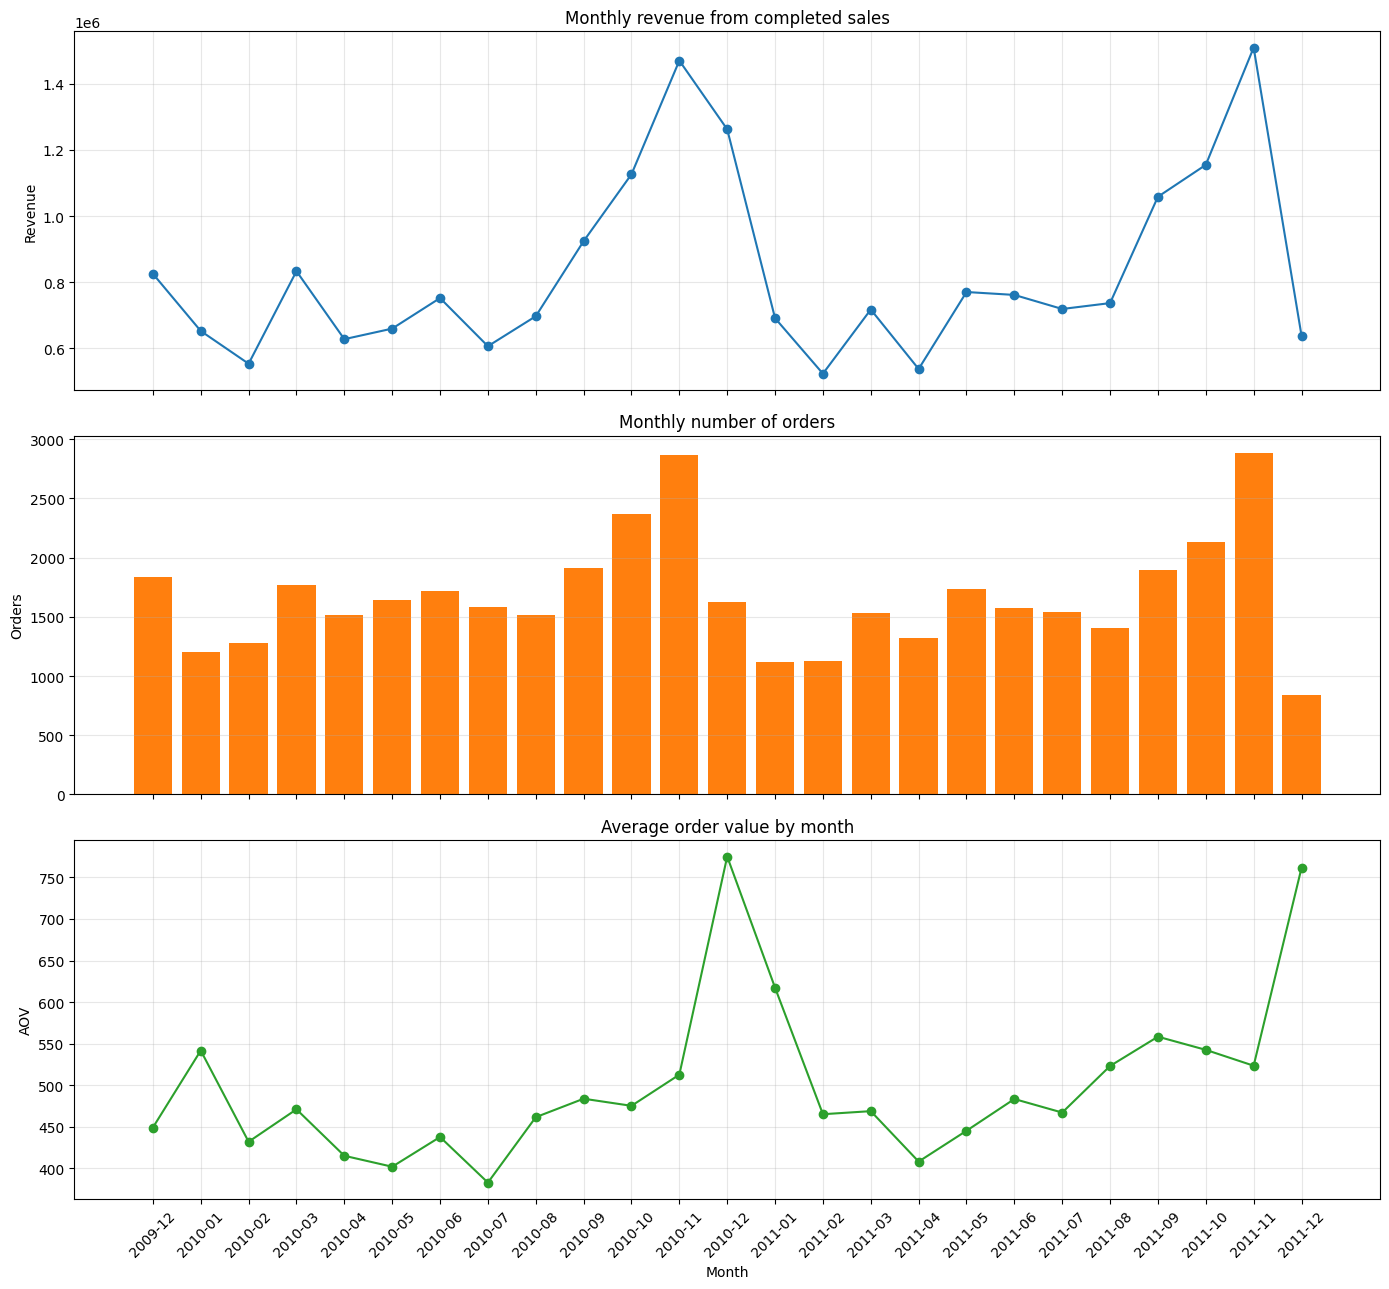

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=True)

axes[0].plot(monthly_sales["month"], monthly_sales["revenue"], marker="o")
axes[0].set_title("Monthly revenue from completed sales")
axes[0].set_ylabel("Revenue")
axes[0].grid(alpha=0.3)

axes[1].bar(monthly_sales["month"], monthly_sales["orders"], color="tab:orange")
axes[1].set_title("Monthly number of orders")
axes[1].set_ylabel("Orders")
axes[1].grid(axis="y", alpha=0.3)

axes[2].plot(monthly_sales["month"], monthly_sales["aov"], marker="o", color="tab:green")
axes[2].set_title("Average order value by month")
axes[2].set_ylabel("AOV")
axes[2].set_xlabel("Month")
axes[2].grid(alpha=0.3)

for axis in axes:
    axis.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Geographic and product concentration

These tables identify the countries and products that contribute most to gross sales. They will be useful inputs for the later customer and retention analysis.

In [13]:
top_countries = (
    analysis_df.loc[~analysis_df["is_return"]]
    .groupby("country", as_index=False)
    .agg(revenue=("revenue", "sum"), orders=("invoice_no", "nunique"))
    .sort_values("revenue", ascending=False)
    .head(10)
)
top_countries["revenue_share_percent"] = (
    top_countries["revenue"] / top_countries["revenue"].sum() * 100
).round(2)
top_countries

,country,revenue,orders,revenue_share_percent
40,United Kingdom,1.771268e+07,38401,87.42
11,EIRE,6.644318e+05,626,3.28
26,Netherlands,5.542323e+05,229,2.74
15,Germany,4.312625e+05,789,2.13
14,France,3.569446e+05,622,1.76
0,Australia,1.699681e+05,95,0.84
34,Spain,1.091785e+05,154,0.54
36,Switzerland,1.010113e+05,93,0.50
35,Sweden,9.190372e+04,105,0.45
10,Denmark,6.986219e+04,43,0.34


## Visual analysis: geographic concentration

The country chart shows whether revenue is diversified or concentrated in one market. This matters when interpreting growth, risk, and future customer analytics.

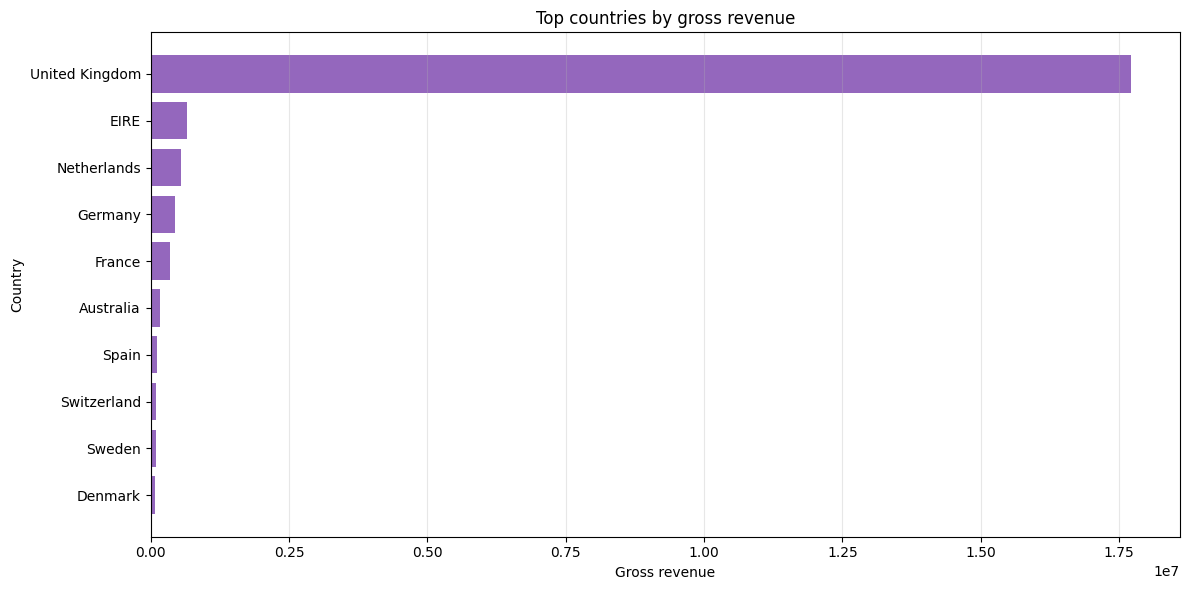

In [14]:
country_chart = top_countries.sort_values("revenue")

fig, axis = plt.subplots(figsize=(12, 6))
axis.barh(country_chart["country"], country_chart["revenue"], color="tab:purple")
axis.set_title("Top countries by gross revenue")
axis.set_xlabel("Gross revenue")
axis.set_ylabel("Country")
axis.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
top_products = (
    analysis_df.loc[~analysis_df["is_return"]]
    .groupby(["stock_code", "description"], dropna=False, as_index=False)
    .agg(revenue=("revenue", "sum"), units_sold=("quantity", "sum"))
    .sort_values("revenue", ascending=False)
    .head(10)
)
top_products

,stock_code,description,revenue,units_sold
2352,22423,REGENCY CAKESTAND 3 TIER,344563.25,27594
6864,M,Manual,341089.85,10058
6862,DOT,DOTCOM POSTAGE,322657.48,1441
6146,85123A,WHITE HANGING HEART T-LIGHT HOLDER,262931.16,96091
3978,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995
4475,47566,PARTY BUNTING,149187.05,28395
6106,85099B,JUMBO BAG RED RETROSPOT,148823.92,78866
5686,84879,ASSORTED COLOUR BIRD ORNAMENT,132187.92,81817
6866,POST,POSTAGE,127597.42,5461
1874,22086,PAPER CHAIN KIT 50'S CHRISTMAS,123141.54,36581


**Data quality note:** top-revenue results include operational codes such as `Manual`, `DOTCOM POSTAGE`, and `POSTAGE`. These are not regular merchandise and should be separated from product performance metrics in the preprocessing or analytics stage.

## Initial findings

The analysis establishes the baseline for the next stages:

- returns must remain identifiable during preprocessing;
- missing `customer_id` values limit customer-level and churn analysis;
- revenue should be calculated from quantity and unit price rather than treated as a raw column;
- monthly sales, country concentration, and product concentration are the first business views;
- the next implementation stage is data validation and preprocessing rules.

## Transaction preprocessing

The reusable preprocessing function cleans the normalized data before analytics. It removes technical errors and exact duplicates, keeps negative quantities as returns, and creates line-level revenue.

In [8]:
from src.data.preprocessing import preprocess_transactions

clean_transactions, report = preprocess_transactions(df)

report_summary = pd.DataFrame(
    {
        "metric": [
            "input_rows",
            "output_rows",
            "removed_duplicates",
            "removed_invalid_rows",
            "removed_zero_quantity_rows",
            "return_rows",
            "net_revenue",
        ],
        "value": [
            report.input_rows,
            report.output_rows,
            report.removed_duplicates,
            report.removed_invalid_rows,
            report.removed_zero_quantity_rows,
            int(clean_transactions["is_return"].sum()),
            round(clean_transactions["revenue"].sum(), 2),
        ],
    }
)

report_summary

,metric,value
0,input_rows,1067371.00
1,output_rows,1033031.00
2,removed_duplicates,34335.00
3,removed_invalid_rows,5.00
4,removed_zero_quantity_rows,0.00
5,return_rows,22496.00
6,net_revenue,19014209.84


## 1. Customer data coverage

Customer-level analytics is only reliable for transactions with a known `customer_id`. We measure the known and unknown portions separately instead of silently dropping anonymous transactions.

In [16]:
customer_coverage = pd.DataFrame(
    {
        "segment": ["known customer", "anonymous transaction"],
        "rows": [
            clean_transactions["customer_id"].notna().sum(),
            clean_transactions["customer_id"].isna().sum(),
        ],
    }
)
customer_coverage["share_percent"] = (
    customer_coverage["rows"] / len(clean_transactions) * 100
).round(2)
customer_coverage

,segment,rows,share_percent
0,known customer,797885,77.24
1,anonymous transaction,235146,22.76


**Interpretation:** anonymous rows can be used for total sales reporting, but they must be excluded from customer retention, RFM, and churn modeling because there is no stable customer key.

## 2. Order economics

The dataset is line-item based, so a single invoice can contain many rows. We aggregate to invoice level to distinguish line value from order value and calculate a meaningful AOV distribution.

In [9]:
orders = (
    clean_transactions.groupby("invoice_no", as_index=False)
    .agg(
        order_value=("revenue", "sum"),
        unique_products=("stock_code", "nunique"),
        units=("quantity", "sum"),
        invoice_date=("invoice_date", "min"),
        customer_id=("customer_id", "first"),
    )
)

positive_orders = orders.loc[orders["order_value"] > 0, "order_value"]
order_value_summary = positive_orders.describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).round(2)
order_value_summary

count     40078.00
mean        510.92
std        1482.31
min           0.19
25%         149.75
50%         302.22
75%         493.40
90%         929.27
95%        1513.38
99%        4408.51
max      168469.60
Name: order_value, dtype: float64

## Visual analysis: order-value distribution

Order values are usually skewed because most customers place regular orders while a small number of invoices are much larger. A logarithmic x-axis helps inspect both typical and high-value orders.

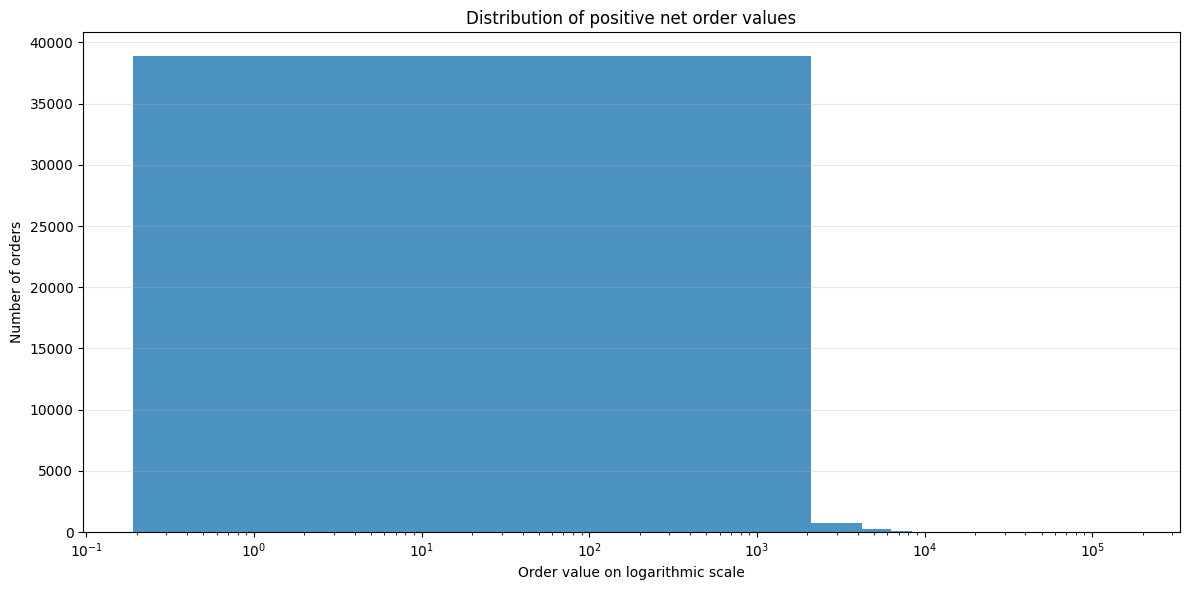

In [10]:
fig, axis = plt.subplots(figsize=(12, 6))
axis.hist(positive_orders, bins=80, color="tab:blue", alpha=0.8)
axis.set_xscale("log")
axis.set_title("Distribution of positive net order values")
axis.set_xlabel("Order value on logarithmic scale")
axis.set_ylabel("Number of orders")
axis.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation:** the median order value is usually more representative than the mean when a small number of wholesale-sized orders create a long right tail. Percentiles help us see that skew before choosing metrics or model features.

## 3. Returns and cancellation behavior

Returns are part of the business signal, not noise. We compare return activity by month and country to identify periods or markets that may require operational investigation.

In [11]:
return_analysis = clean_transactions.assign(
    month=clean_transactions["invoice_date"].dt.to_period("M").astype(str)
).groupby("month", as_index=False).agg(
    total_revenue=("revenue", "sum"),
    return_value=("revenue", lambda values: -values[values < 0].sum()),
    sales_lines=("is_return", lambda values: (~values).sum()),
    return_lines=("is_return", "sum"),
)
return_analysis["return_rate_percent"] = (
    return_analysis["return_lines"]
    / (return_analysis["sales_lines"] + return_analysis["return_lines"])
    * 100
).round(2)
return_analysis.tail(12)

,month,total_revenue,return_value,sales_lines,return_lines,return_rate_percent
13,2011-01,558448.560,131363.05,34104,796,2.28
14,2011-02,497026.410,25519.15,26961,518,1.89
15,2011-03,682013.980,34201.28,35609,830,2.28
16,2011-04,492367.841,44600.65,28957,744,2.50
17,2011-05,722094.100,47202.51,36044,738,2.01
18,2011-06,689977.230,70569.78,35793,816,2.23
19,2011-07,680156.991,37919.13,38466,801,2.04
20,2011-08,703510.580,54330.80,34345,717,2.04
21,2011-09,1017596.682,38838.51,48962,899,1.80
22,2011-10,1069368.230,81895.50,58629,1340,2.23


In [17]:
return_by_country = (
    clean_transactions.loc[clean_transactions["is_return"]]
    .groupby("country", as_index=False)
    .agg(
        return_lines=("is_return", "size"),
        return_value=("revenue", lambda values: -values.sum()),
    )
    .sort_values("return_value", ascending=False)
    .head(10)
)
return_by_country

,country,return_lines,return_value
34,United Kingdom,19683,1265833.21
8,EIRE,508,48813.53
11,France,385,28722.70
23,Norway,18,20866.59
29,Spain,91,17319.05
12,Germany,899,13060.55
28,Singapore,7,12158.90
14,Hong Kong,6,9855.02
21,Netherlands,47,5707.39
25,Portugal,58,4879.85


## Visual analysis: returns over time

The return-rate chart helps separate normal sales growth from growth accompanied by a deterioration in transaction quality.

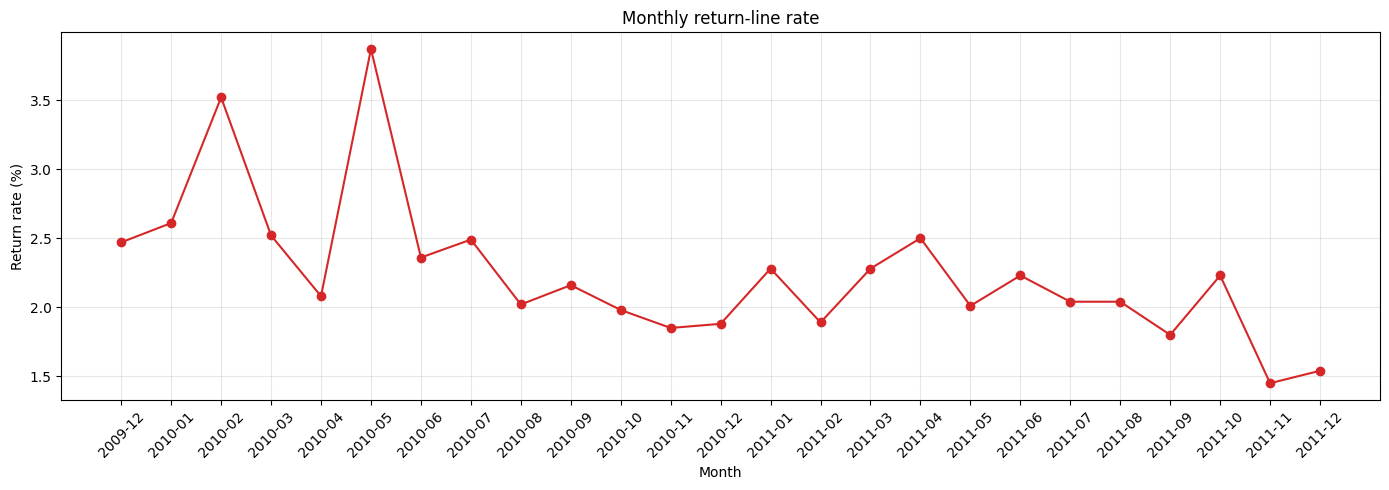

In [12]:
fig, axis = plt.subplots(figsize=(14, 5))
axis.plot(
    return_analysis["month"],
    return_analysis["return_rate_percent"],
    marker="o",
    color="tab:red",
)
axis.set_title("Monthly return-line rate")
axis.set_xlabel("Month")
axis.set_ylabel("Return rate (%)")
axis.tick_params(axis="x", rotation=45)
axis.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation:** a high return value is a diagnostic signal. It does not prove a product or country is underperforming, but it identifies where we should investigate product quality, fulfillment, or customer-experience issues.

## 4. Customer value and RFM preparation

RFM means Recency, Frequency, and Monetary value. We first build the customer-level table; scoring and segmentation will be implemented in the next customer analytics stage.

In [18]:
customer_sales = clean_transactions.loc[
    clean_transactions["customer_id"].notna()
    & ~clean_transactions["is_return"]
].copy()
snapshot_date = customer_sales["invoice_date"].max() + pd.Timedelta(days=1)

customer_rfm = (
    customer_sales.groupby("customer_id", as_index=False)
    .agg(
        last_purchase=("invoice_date", "max"),
        frequency=("invoice_no", "nunique"),
        monetary=("revenue", "sum"),
        products_bought=("stock_code", "nunique"),
    )
)
customer_rfm["recency_days"] = (
    snapshot_date - customer_rfm["last_purchase"]
).dt.days
customer_rfm = customer_rfm[
    [
        "customer_id",
        "recency_days",
        "frequency",
        "monetary",
        "products_bought",
    ]
].sort_values("monetary", ascending=False)
customer_rfm.head(10)

,customer_id,recency_days,frequency,monetary,products_bought
5695,18102,1,145,580987.04,382
2279,14646,2,152,528602.52,962
1791,14156,10,156,313437.62,1446
2541,14911,1,398,291420.81,2550
5053,17450,8,51,244784.25,145
1332,13694,4,143,195640.69,896
5112,17511,3,60,172132.87,657
4064,16446,1,2,168472.50,3
4298,16684,4,55,147142.77,184
68,12415,24,28,144458.37,498


**Interpretation:**

- lower `recency_days` means a more recently active customer;
- higher `frequency` means more repeat orders;
- higher `monetary` means greater historical sales value;
- `products_bought` adds a simple breadth-of-purchase feature.

These features are suitable inputs for RFM segmentation and a first churn baseline.